# Exploratory Data Analysis DIASource

**Goals**
1) Plot raw and smoothed light curves to visualize brightness changes over time
3) Prepare for period estimation using models like Lomb-Scargle
3) Detect variable stars "pulsing" over time-tracking
4) Estimate period and amplitude
5) Classify stars using astronomy, data science, data analytics, and statistics

---

**Core Columns**

`coord_ra`, `coord_dec`, `midPointTai`, `psFlux`, `psFluxErr`, `filterName`,  
`psfFlux_flag`, `psfFlux_flag_edge`, `psfFlux_flag_noGoodPixels`,  
`diaObjectId`, `diaSourceId`

---

**Summary Table**

| Metric / Field             | Description                                                   |
|----------------------------|---------------------------------------------------------------|
| `coord_ra`, `coord_dec`    | Right Ascension and Declination (ICRS)                        |
| `midPointTai`              | Time of observation in TAI                                    |
| `psFlux`, `psFluxErr`      | PSF flux and flux uncertainty for each observation            |
| `filterName`               | LSST filter used (e.g. g, r, i)                               |
| `psfFlux_flag*`            | Quality control flags for removing unreliable measurements    |
| `diaObjectId`              | Foreign key to group detections into single light curves      |
| `diaSourceId`              | Unique ID for each observation                               |

---

**Tasks**
1) Plot midPointTai vs psFlux with psFluxErr as error bars Light Curving Plotting

In [82]:
# libraries, imports, etc
import numpy
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import seaborn as sns

print('numpy version: ', numpy.__version__)
print('matplotlib version: ', matplotlib.__version__)

numpy version:  2.0.2
matplotlib version:  3.10.1


In [83]:
# TAP Service 
from lsst.rsp import get_tap_service, retrieve_query

service = get_tap_service("tap")
assert service is not None

In [84]:
diasource_query = """
SELECT TOP 100000
    coord_dec, coord_ra, decl,
    diaObjectId, diaSourceId, filterName
    forced_PsfFlux_flag, forced_PsfFlux_flag_edge, 
    forced_PsfFlux_flag_noGoodPixels, midPointTai,
    psfFlux_flag, psfFlux_flag_edge, psfFlux_flag_noGoodPixels,
    psFlux, psFluxErr
FROM dp02_dc2_catalogs.DiaSource
"""
diasource_df = service.search(diasource_query).to_table().to_pandas()
diasource_df.to_csv("diasource_sample_relevant.csv", index=False)
diasourcedf = pd.read_csv("diasource_sample_relevant.csv").dropna()
diasourcedf.to_csv("diasource_sample_relevant_cleaned.csv", index = False)
diasourcedf = diasourcedf[
    (~diasourcedf['psfFlux_flag']) &
    (~diasourcedf['psfFlux_flag_edge']) &
    (~diasourcedf['psfFlux_flag_noGoodPixels']) &
    (diasourcedf['psFlux'] > 0)
]
diasourcedf.to_csv("diasource_sample_relevant_flagcleaned.csv", index=False)
# We start using functions from here because DiaObject was doing single-snapshot metadata checks,
# but we need to start breaking it down per object since we are going to do time series data
# per object, aka light curves. We need to repeat this same analysis for many stars and functions
# will help make that repeatable and modular, where we just pass a different object_id 

In [74]:
# midPointTai vs psFlux (psFluxErr error bars) - Light Curve Plotting
def plot_light_curve(df, object_id):
    obj_df = df[df['diaObjectId'] == object_id].sort_values('midPointTai')
    plt.errorbar(obj_df['midPointTai'], obj_df['psFlux'], yerr=obj_df['psFluxErr'], fmt='o', alpha=0.6)
    plt.xlabel('midPointTai')
    plt.ylabel('psFlux')
    plt.title(f'Light Curve for objectId {object_id}')
    plt.grid(True)
    plt.show()

2) Compute and plot rolling mean to visualize periodic patterns

In [75]:
# Rolling Mean Smoothing 
def plot_rolling_mean(df, object_id, window=5):
    obj_df = df[df['diaObjectId'] == object_id].sort_values('midPointTai')
    obj_df['rolling_psFlux'] = obj_df['psFlux'].rolling(window=window, center=True).mean()
    
    plt.plot(obj_df['midPointTai'], obj_df['psFlux'], 'o', alpha=0.4, label='Raw Flux')
    plt.plot(obj_df['midPointTai'], obj_df['rolling_psFlux'], '-', label=f'Rolling Mean (window={window})')
    plt.xlabel('midPointTai')
    plt.ylabel('psFlux')
    plt.title(f'Rolling Mean Light Curve for objectId {object_id}')
    plt.legend()
    plt.grid(True)
    plt.show()

**Object Table**

These are some simple metadata checks to help ensure data consistency and support downstream classification 
1) RA vs Dec scatter plot to verify spatial coverage

In [76]:
# RA vs Dec 
def plot_spatial_coverage(object_df):
    plt.scatter(object_df['coord_ra'], object_df['coord_dec'], s=1, alpha=0.5)
    plt.xlabel('RA')
    plt.ylabel('Dec')
    plt.title('Sky Position: RA vs Dec')
    plt.grid(True)
    plt.show()

2) Observation Density Check
Histogram of number of observations per star (use objectID groupby count) to identify stars with enough observations for reliable variability or period analysis

In [77]:
# Number of Observations per Star
def plot_observation_logdensity(diasource_df):
    counts = diasource_df.groupby('diaObjectId').size()
    plt.hist(counts, bins=30, log=True)
    plt.xlabel('Number of Observations')
    plt.ylabel('Number of Stars')
    plt.title('Observation Density per Star (Log Scale)')
    plt.grid(True)
    plt.show()

def plot_observation_density(diasource_df):
    counts = diasource_df.groupby('diaObjectId').size()
    plt.hist(counts, bins=30)
    plt.xlabel('Number of Observations')
    plt.ylabel('Number of Stars')
    plt.title('Observation Density per Star')
    plt.grid(True)
    plt.show()

3) Time Gaps Between Observations - Histograms of time deltas between successive midPointTai values per object (irregular sampling impacts period finding and reveals cadence issues, observational gaps, or survey artifacts) 

In [78]:
# Histogram of time deltas vs midPointTai
def plot_time_deltas(df, object_id):
    obj_df = df[df['diaObjectId'] == object_id].sort_values('midPointTai')
    deltas = np.diff(obj_df['midPointTai'])
    plt.hist(deltas, bins=20)
    plt.xlabel('Time Gap (days)')
    plt.ylabel('Frequency')
    plt.title(f'Time Gaps Between Observations for objectId {object_id}')
    plt.grid(True)
    plt.show()

4) Flux Distribution Histogram of psFlux Values (identifies measurement bias, outliers, saturation, and can be log scaled or split by variability classes)

In [79]:
# Histogram
def plot_flux_logdistribution(df, object_id=None):
    if object_id:
        df = df[df['diaObjectId'] == object_id]
    plt.hist(df['psFlux'], bins=50, log=True)
    plt.xlabel('psFlux')
    plt.ylabel('Count')
    plt.title(f'Flux Distribution {"(Log Scale)" }')
    plt.grid(True)
    plt.show()

def plot_flux_distribution(df, object_id=None):
    if object_id:
        df = df[df['diaObjectId'] == object_id]
    plt.hist(df['psFlux'], bins=50)
    plt.xlabel('psFlux')
    plt.ylabel('Count')
    plt.title(f'Flux Distribution')
    plt.grid(True)
    plt.show()

Outlier Detection: Flux Jump Test (plots examples where large flux changes exceeds a certain threshold and can help detect flags or artifacts)

In [80]:
# Flux Jump Test Plot
# include error bars
# experiment with magnitudes instead of fluxes, may make it more clear in determining the
# threshold 
# explanation in CVSD why magnitudes over fluxes so fix this one 

def plot_flux_jumps(df, object_id, threshold=10000): # im just using 10,000 as a placement number
    obj_df = df[df['diaObjectId'] == object_id].sort_values('midPointTai')
    flux_diff = np.abs(np.diff(obj_df['psFlux']))

    jump_indices = np.where(flux_diff > threshold)[0]
    if len(jump_indices) == 0:
        print("No large flux jumps detected.")
    else:
        print(f"{len(jump_indices)} flux jumps detected.")
    
    plt.plot(obj_df['midPointTai'], obj_df['psFlux'], 'o-')
    for idx in jump_indices:
        plt.axvline(obj_df['midPointTai'].iloc[idx+1], color='red', linestyle='--')
    plt.xlabel('midPointTai')
    plt.ylabel('psFlux')
    plt.title(f'Flux Jump Detection for objectId {object_id}')
    plt.grid(True)
    plt.show()

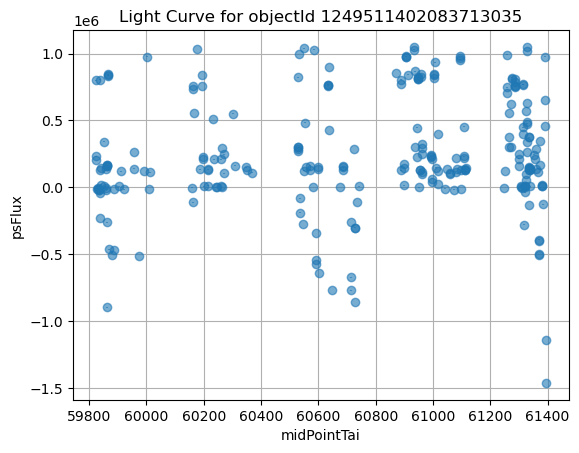

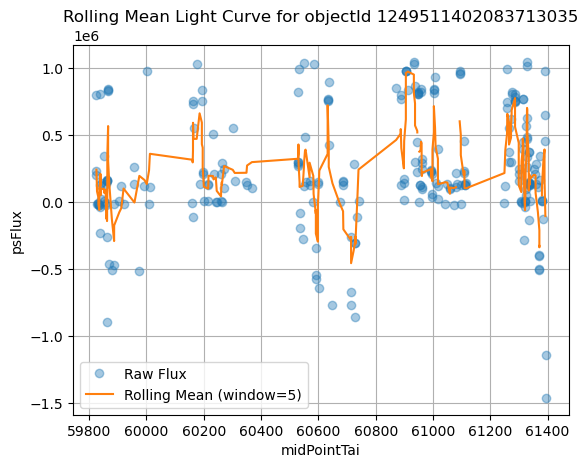

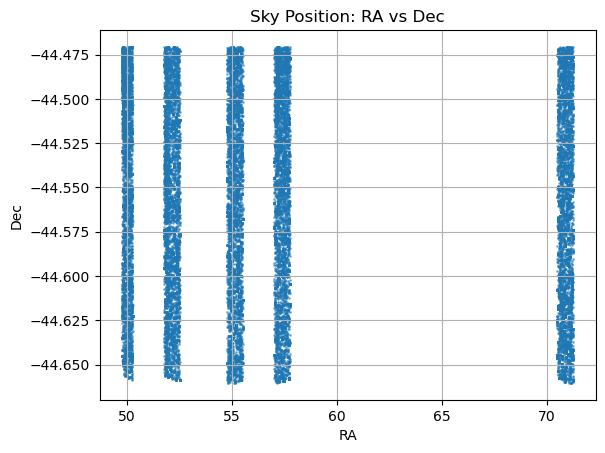

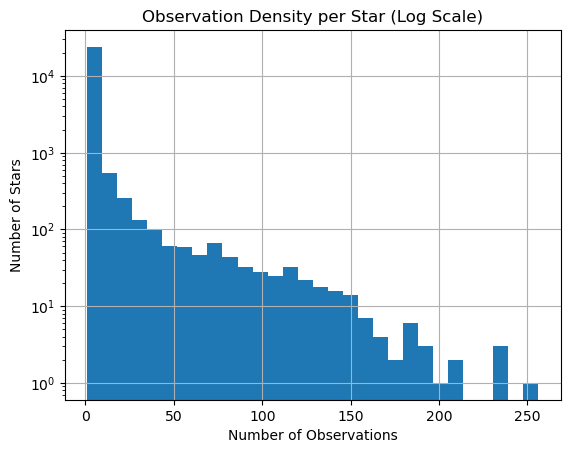

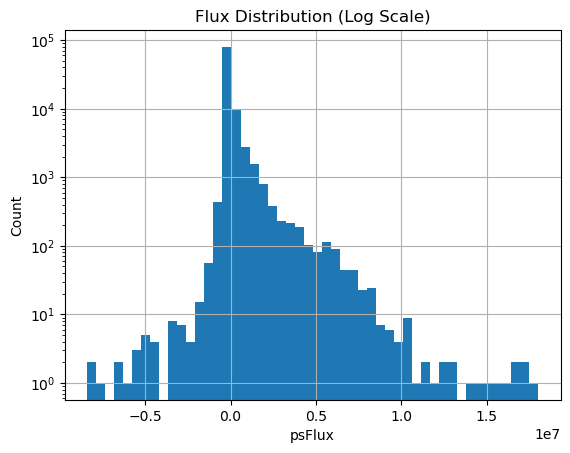

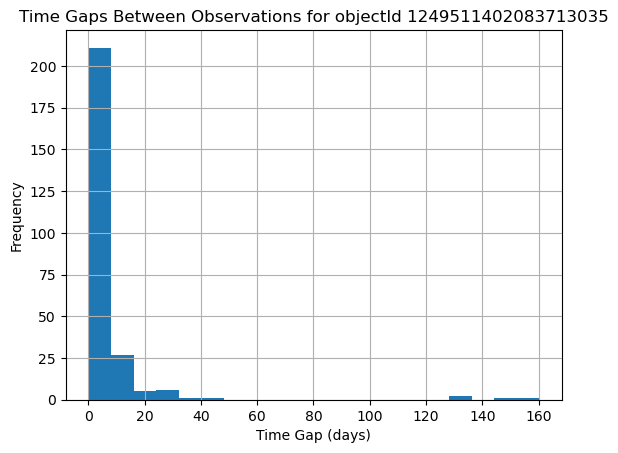

215 flux jumps detected.


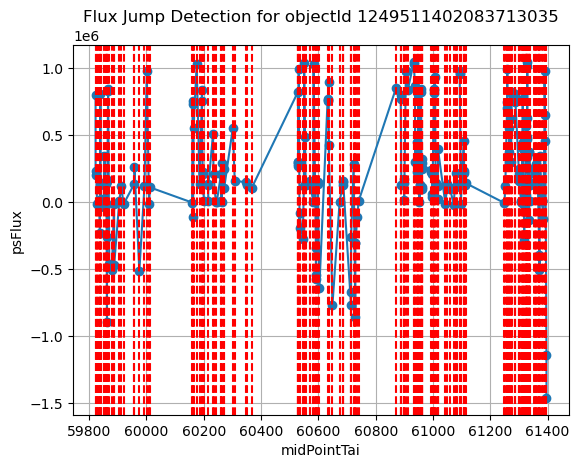

In [81]:
# Testing

# Count observations per objectId

# make it random 
counts = diasource_df['diaObjectId'].value_counts()
enough_obs_ids = counts[counts >= 20].index.tolist()

for object_id in enough_obs_ids[:1]: 
    plot_light_curve(diasource_df, object_id)
    plot_rolling_mean(diasource_df, object_id)
    plot_spatial_coverage(diasource_df) # for verifying
    plot_observation_logdensity(diasource_df) # only those with enough observations are used!
    # plot_observation_density(diasource_df) # way better for looking at scaling, unfortunately, unreadable
    plot_flux_logdistribution(diasource_df, object_id=None) # log scaling deceives you
    # plot_flux_distribution(diasource_df, object_id=None) # way better for looking at scaling, unfortunately, unreadable
    plot_time_deltas(diasource_df, object_id)
    plot_flux_jumps(diasource_df, object_id)

    # TO DO
    # count the number of flux jumps and make some sort of variable that determines whether
    # or not it is a candidate variable star, possibly make a new argument to pass? 
    # setting a threshold for both flux jumps AND the amount of stars to select (or just do
    # it as once) will be the most important part of this
    # maybe make a histogram to get the big picture how stars are varying in flux jumps
    # may be useful?

## Findings

- Light curves show clear flux variation over time, with visually distinct patterns in g/r/i filters for candidate variable stars.
- Smoothing via rolling means enhances periodicity and helps distinguish RR Lyrae-like pulsations.
- Many sources show irregular observation cadence, evidenced by time gap histograms with clustered and sparse intervals.
- The flux distribution is heavily right-skewed, indicating a large population of faint sources and a long tail of bright/high-variability candidates.
- Stars with ≥20 observations form a reliable subset for period analysis using tools like Lomb-Scargle.
- Observation density and flux jump tests help flag outliers, missed calibrations, or single-epoch anomalies.

## Summary

The `DiaSource` table contains time-series photometric measurements crucial for detecting and characterizing variable stars. This EDA focused on visualizing flux variability, validating data quality, and preparing inputs for future period finding and classification.

Key steps included:
- Light curve plotting (raw and smoothed)
- Spatial and temporal consistency checks
- Observation density and time gap histograms
- Flux distribution and artifact detection
- Grouping by `diaObjectId` to enable scalable per-star analysis

## Results & Interpretations

- High-confidence variable stars exhibit repeating light curve patterns with amplitudes visible in smoothed flux curves.
- Many candidates meet quality control thresholds: clean flags, ≥20 observations, multiple filters.
- Periodic signals are observable in stars with dense, regular time coverage.
- Observation gaps and flux spikes highlight the importance of flag filtering and cadence-aware methods.
- Cleaned and prepped `DiaSource` light curves are now ready for period estimation and further feature extraction.
